In [2]:
pip install coolprop


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 78.1 MB/s eta 0:00:00


In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import iv, kv
from CoolProp.CoolProp import PropsSI

In [49]:

# ------------------- USER INPUTS --------------------------------------------
# Units: use SI (meters, seconds, Kelvin)
T_inf = 43.8 + 273.15      # K (temp of air entering fin assembly. consider +20C across charger)
Tb   = 48 + 273.15         # K (approx prime surf temp of fins - only used to calculate gas properties)
T_film = 0.5*(Tb + T_inf)  # K
#print(f"film temp = {T_film:0.1f}")
P = 101325                 # Pa
u = 0.5                    # Air speed in m/s

# Fin geometry (convert mm to m if inputs were mm)
W = 45e-3                  # m  (plate width)
L = 45e-3                  # m  (flow length)
#t = 0.5e-3                 # m  (fin thickness)
#S = 1.5e-3                 # m  (pitch)
Dp = 8e-3                  # m  (heat pipe OD)
r1 = Dp/2                  # m
adiabatic_tip = True       # Assume adiabatic tip?
num_heatpipes = 2          # Number of heatpipes entering fin assembly

k_fin = 200                # W/m-K (fin material conductivity)

# All proceeding calculations are done assuming adiabatic midplanes between
# equally spaced heat pipes

In [52]:
# ------------------- CALCULATIONS --------------------------------------------

def calculate_R_o_total(
    W,
    L,
    t,
    N,
    Dp,
    r1,
    adiabatic_tip,
    num_heatpipes,
    k_fin
):

  N = np.floor(68e-3/S)         #    (num fins)

# Calculate effective W
  W = W/num_heatpipes

# Longitudinal-flow passage geometry
  H = S - t                # m  (gap height)
  assert H > 0, "Fin pitch must exceed fin thickness."
  Dh = (2*W*H)/(W+H)       # hydraulic diameter of a passage

# Number of open channels
  N_ch = max(N-1, 1)
  A_min = N_ch*(W*H - Dp*H)  # m^2 total minimum flow area (acount for tube blockage)

# ------------------- FLUID PROPERTIES @ film temp & ambient P ---------------
  rho_air = PropsSI('D', 'T', T_film, 'P', P, 'Air')
  mu_air  = PropsSI('V', 'T', T_film, 'P', P, 'Air')
  k_air   = PropsSI('L', 'T', T_film, 'P', P, 'Air')
  Pr      = PropsSI('PRANDTL', 'T', T_film, 'P', P, 'Air')

  Re = rho_air * u * Dh / mu_air
  #print(f"Re = {Re:.0f}, Pr = {Pr:.2f}")

  # ------------------- HEAT TRANSFER COEFFICIENT ------------------------------
  # Use Gnielinski only if turbulent
  if Re >= 3000:
      # Petukhov smooth-pipe explicit f (natural log)
      f = (0.79*math.log(Re) - 1.64)**-2
      Nu = (f/8.0) * (Re - 1000.0) * Pr / (1.0 + 12.7*math.sqrt(f/8.0)*(Pr**(2.0/3.0) - 1.0))
  else:
      # Thermally developing laminar entrance flow (Shah/London-type)
      Nu = 1.86 * ((Re*Pr*Dh/L)**(1/3)) * ((mu_air/PropsSI('V','T',Tb,'P',P,'Air'))**0.14)
      # Clip to fully-developed parallel-plate constant-T upper bound (~7.54) as a sanity check
      Nu = min(Nu, 7.54)

  h = k_air * Nu / Dh
  #print(f"h = {h:.1f} W/m^2-K")

# ------------------- BESSEL WRAPPERS ---------------------------------------
  def I0(x): return iv(0, x)
  def I1(x): return iv(1, x)
  def K0(x): return kv(0, x)
  def K1(x): return kv(1, x)

  # ------------------- ANNULAR FIN EFFICIENCY ---------------------------------
  # Circularization of rectangular fin (two-sided area, thin-fin assumption)
  # Two-sided area excluding tube hole: Af_2s ≈ 2*(W*L - π r1^2)
  Af_2s = 2.0*(W*L - math.pi*r1**2)

  # Match to 2π(r2^2 - r1^2)
  r2 = math.sqrt( (Af_2s/(2.0*math.pi)) + r1**2 )

  # Radius correction to account for convective tip
  r2c = r2 + t/2.0

  # Equivalent fin length to match circularization
  Leq = r2-r1
  #print(r2)

  if adiabatic_tip:
    # adiabiatic tip = no lenth correction
    r2_use = r2
  else:
    # convective tip = length correcton
    r2_use = r2c
    #print(f"r2c = {r2c:0.4f}")

  # Fin parameter for plate fin
  m = math.sqrt( 2.0*h / (k_fin*t) )
  #print(f"fin parameter = {m:0.1f}")

  x1 = m*r1
  x2 = m*r2_use

  C2 = (2.0*r1/m) / (r2_use**2 - r1**2)

  # Efficiency for annular fin with adiabatic tip (textbook Eq. like your 3.96)
  eta_f = C2 * (K1(x1)*I1(x2) - I1(x1)*K1(x2)) / (I0(x1)*K1(x2) + K0(x1)*I1(x2))
  #print(f"individual fin efficiency η_f = {eta_f:.3f}")

  # ------------------- FIG3.2 CONVECTIVE TIP SANITY CHECK ---------------------------------------
  Lc = Leq + t/2
  Ap = Lc*t
  R = r2c/r1
  #print(f"radius_ratio = {R:.2f}")
  eta_ref = Lc**(3/2)*math.sqrt(h/(k_fin*Ap))
  #print(f"eta_ref = {eta_ref:.2f}")

  # Individual fin thermal resistance
  Rtf = 1 / (h*Af_2s*eta_f)
  #print(f"individual fin resistance = {Rtf:0.2f}")

  # ------------------- FIN ASSEMBLY CALCULATIONS ---------------------------------------
  # Fin assembly thermal resistance
  Ab = math.pi*Dp*H*(N-1) # prime surface (base) area
  At = N*Af_2s+Ab # total assembly surface area
  eta_o = 1 - (N*Af_2s/At)*(1-eta_f) # overall surface efficiency
  #print(f"fin assembly efficiency η_o = {eta_o:.3f}")
  R_o_total = 1 / (h*At*eta_o)/num_heatpipes # divide by num heatpipes to model resistances in parallel
  #print(f"fin assembly resistance R_o = {R_o_total:0.5f}")
  return R_o_total

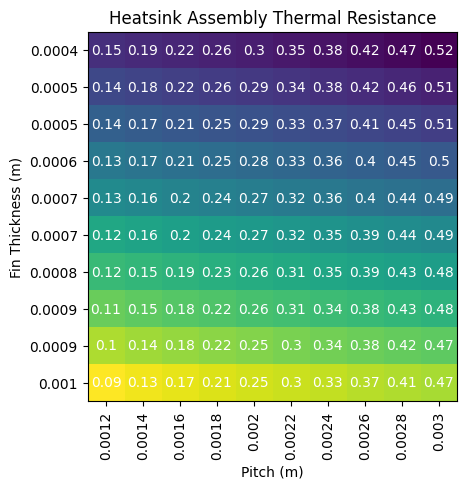

In [53]:
size = 10 # Number of trials
# Fin thickness and pitch optimizaton
t_array = np.linspace(0.4e-3, 1e-3, size)
S_array = np.linspace(1.2e-3, 3e-3, size)

fig, ax = plt.subplots()
R_o_total_array = np.zeros((size,size))
for S_index, S in enumerate (S_array):
  for t_index, t in enumerate (t_array):
    R_o_total_array[S_index, t_index] = calculate_R_o_total(
        W,
        L,
        t,
        S,
        Dp,
        r1,
        adiabatic_tip,
        num_heatpipes,
        k_fin
    )
    text = ax.text(S_index, t_index, np.round(R_o_total_array[S_index, t_index],2), ha="center", va="center", color="w")

im = ax.imshow(R_o_total_array)
ax.set_xticks(range(len(S_array)), labels=np.round(S_array,4), rotation=90)
ax.set_yticks(range(len(t_array)), labels=np.round(t_array,4))
plt.xlabel("Pitch (m)")
plt.ylabel("Fin Thickness (m)")
ax.set_title("Heatsink Assembly Thermal Resistance")
plt.show()



In [6]:
# ------------------- RESISTIVE CIRCUIT CALCULATIONS ---------------------------------------
#T_charger - thermal paste - heat pipe - thermal epoxy - fin - T_film

q_dot = 1479*0.065 # watts of heat generation
q_bias = 0.85 # thermal bias towards side of charger being cooled
q_design = q_dot*q_bias # Total heat that needs to be dissipated
print(f"Required dissipative power (W) = {q_design:0.2f}")

T_charger = 53 +273 # temp of charger heat spreader plate

# Following calculations are for the entire assZembly (both heat pipes)

L_paste = 0.25e-3 # thermal paste thickness
k_paste = 31.4 # thermal paste conducitivity
A_paste = 1581e-6 # thermal paste contact area
R_paste = L_paste/(k_paste*A_paste)
R_paste_dist = L_paste/k_paste
print(f"Thermal paste distrbuted thermal resistance = {R_paste_dist:0.3e}")


L_pipe = 200e-3
k_pipe = 20000 # Adjust HP thermal conductivity so theta_pipe ~ 2-5C
A_pipe = math.pi*r1**2
R_pipe = L_pipe/(k_pipe*A_pipe)/num_heatpipes
#print(f"Heat pipe thermal resistance = {R_pipe:0.2f}")

L_epoxy = 0.076e-3 #epoxy thickness
k_epoxy = 1.4 # epoxy thermal conductivity
A_epoxy = Ab*num_heatpipes # epoxy contact area
R_epoxy = L_epoxy/(k_epoxy*A_epoxy)
R_epoxy_dist = L_epoxy/k_epoxy
print(f"Epoxy distributed thermal resistance = {R_epoxy_dist:0.3e}")

q_dot_pred = (T_charger-T_inf)/(R_paste+R_pipe+R_epoxy+R_o_total)
print(f"Predicted dissipative power (W)= {q_dot_pred:0.4f}")

theta_pipe = q_dot_pred*R_pipe
print(f"heat pipe delta T = {theta_pipe:0.2f}")

theta_assem = q_dot_pred*(R_paste+R_pipe+R_epoxy)
print(f"Heatsink assembly temp difference {theta_assem:0.2f}")

Required dissipative power (W) = 81.71
Thermal paste distrbuted thermal resistance = 7.962e-06


NameError: name 'Ab' is not defined

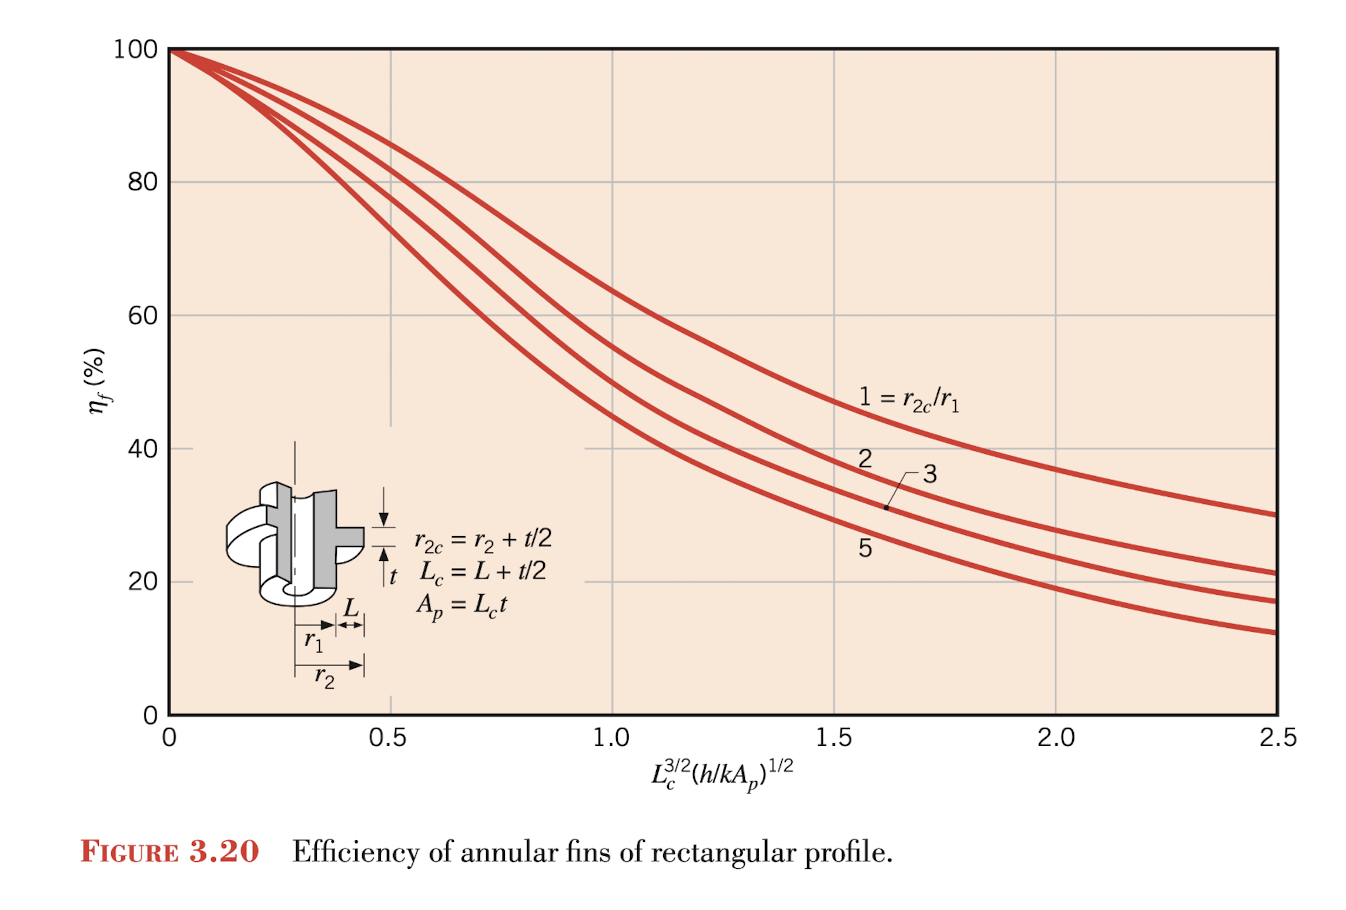